### Headers

In [3]:
import numpy as np
import matplotlib.pyplot as plt

### Required Parameters

In [4]:
N=10000
sigma=1
case=4

### Normal Distribution

In [5]:
def normalDist(mu,sigma,N):
  samples=[]
  while len(samples)<N:
    u1=np.random.uniform(-1,1)
    u2=np.random.uniform(-1,1)
    s=u1**2 + u2**2
    if s==0 or s>=1:
      continue
    k=np.sqrt((-2*np.log(s))/s)
    x=u1*k
    y=u2*k
    xprime=mu+(sigma*x)
    yprime=mu+(sigma*y)
    samples.append(xprime)
    if len(samples)<N:
       samples.append(yprime)
  return np.array(samples)

### Isotropic case

In [6]:
def generate_isotropic(mu,sigma,N):
  x1=normalDist(mu[0],sigma,N)
  x2=normalDist(mu[1],sigma,N)
  X=np.column_stack((x1,x2))
  return X

### Diagonal case

In [7]:
def generate_diagonal(mu,sigma_x,sigma_y,N):
  x1=normalDist(mu[0],sigma_x,N)
  x2=normalDist(mu[1],sigma_y,N)
  X=np.column_stack((x1,x2))
  return X

### Full Covariance case
*Transformation:*

$Z \sim \mathcal{N}(0, \mathbf{I}) \longrightarrow X \sim \mathcal{N}(\mu, \Sigma)$

*Decomposition of Covariance Matrix:*

$\mathbf{C} = \mathbf{V} \mathbf{\Lambda} \mathbf{V}^T$$

*Square Root of Covariance Matrix:*

$\mathbf{C}^{1/2} = \mathbf{V} \mathbf{\Lambda}^{1/2} \mathbf{V}^T$$

*Linear Transformation to Generate Samples:*

$X = Z \mathbf{C}^{1/2} + \mu$$

In [8]:
def generate_full(mu,cov,N):
  # Z∼N(0,I)⟶X∼N(μ,Σ)
  Z=np.column_stack((normalDist(0,1,N),normalDist(0,1,N)))
  eigenvalues, eigenvectors=np.linalg.eigh(cov)
  sqrt_eigenvalues=np.sqrt(eigenvalues)
  Lambda_sqrt=np.diag(sqrt_eigenvalues)
  # C=VΛVT
  # C1/2=VΛ1/2VT
  C_sqrt=eigenvectors@Lambda_sqrt@eigenvectors.T
  # X=ZC1/2+μ
  X=Z@C_sqrt.T+mu
  return X

### Define cases

In [9]:
if case==1:
  #Isotropic+identical covariance
  C1=generate_isotropic([2,5],1,N)
  C2=generate_isotropic([8,3],1,N)
  C3=generate_isotropic([5,9],1,N)
elif case==2:
  #Isotropic+Different covariance
  C1=generate_isotropic([2,5],1,N)
  C2=generate_isotropic([8,3],2,N)
  C3=generate_isotropic([5,9],0.5,N)
elif case==3:
  #Diagonal+identical covariance
  C1=generate_diagonal([2,5],2,1,N)
  C2=generate_diagonal([8,3],2,1,N)
  C3=generate_diagonal([5,9],2,1,N)
elif case==4:
  #Diagonal+Different covariance
  C1=generate_diagonal([2,5],2,1,N)
  C2=generate_diagonal([8,3],1,2,N)
  C3=generate_diagonal([5,9],3,0.5,N)
elif case==5:
  #Full+Identical covariance
  cov=np.array([[4,1.5],[1.5,2]])
  C1=generate_full([2,5],cov,N)
  C2=generate_full([8,3],cov,N)
  C3=generate_full([5,9],cov,N)
elif case==6:
  #Full+Different covariance
  cov1=np.array([[4,1.5],[1.5,2]])
  cov2=np.array([[2,-1],[-1,3]])
  cov3=np.array([[5,2],[2,2]])
  C1=generate_full([2,5],cov1,N)
  C2=generate_full([8,3],cov2,N)
  C3=generate_full([5,9],cov3,N)

### Generated Data Visulaization

Class 1: (10000, 2)
Class 2: (10000, 2)
Class 3: (10000, 2)


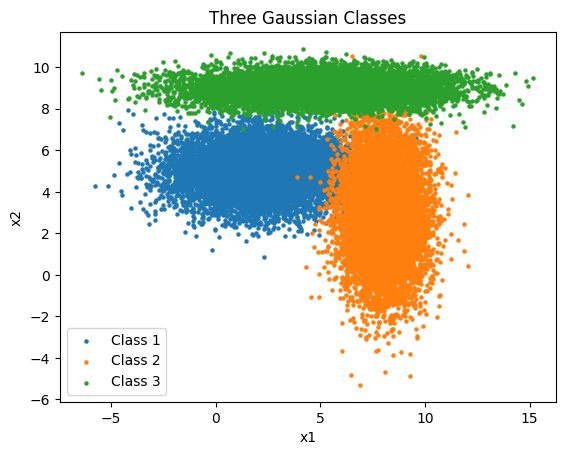

In [10]:
# Check shapes
print("Class 1:", C1.shape)
print("Class 2:", C2.shape)
print("Class 3:", C3.shape)

# Plot
plt.scatter(C1[:, 0], C1[:, 1], s=5, label="Class 1")
plt.scatter(C2[:, 0], C2[:, 1], s=5, label="Class 2")
plt.scatter(C3[:, 0], C3[:, 1], s=5, label="Class 3")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Three Gaussian Classes")
plt.legend()
plt.show()

### Train and test split

In [11]:
# Train and Test split
train_ratio=0.8
N_train=int(train_ratio*N)
N_test=N-N_train
np.random.shuffle(C1)
np.random.shuffle(C2)
np.random.shuffle(C3)
# Split Class 1
C1_train=C1[:N_train]
C1_test=C1[N_train:]
# Split Class 2
C2_train=C2[:N_train]
C2_test=C2[N_train:]
# Split Class 3
C3_train=C3[:N_train]
C3_test=C3[N_train:]

# Check shapes
print("\nTraining data:")
print("Class 1:",C1_train.shape)
print("Class 2:",C2_train.shape)
print("Class 3:",C3_train.shape)
print("\nTesting data:")
print("Class 1:",C1_test.shape)
print("Class 2:",C2_test.shape)
print("Class 3:",C3_test.shape)


Training data:
Class 1: (8000, 2)
Class 2: (8000, 2)
Class 3: (8000, 2)

Testing data:
Class 1: (2000, 2)
Class 2: (2000, 2)
Class 3: (2000, 2)


### Estimation of parameters:

mean: $$\hat{\mu} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{x}_i$$

covariance: $$\mathbf{\Sigma} = \frac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i - \hat{\mu})(\mathbf{x}_i - \hat{\mu})^T $$


In [12]:
def estimate_parameters(X):
    N_sample=X.shape[0]
    # sum(x)/N
    mean=np.sum(X, axis=0)/N_sample
    # sum((x-mean)(x-mean)T)/N
    X_center=X-mean
    covariance=(X_center.T @ X_center)/N_sample
    return mean,covariance

mu1_est,cov1_est=estimate_parameters(C1_train)
mu2_est,cov2_est=estimate_parameters(C2_train)
mu3_est,cov3_est=estimate_parameters(C3_train)
print("\nEstimated parameters")
print("\nClass 1:")
print("Mean =",mu1_est)
print("Covariance =")
print(cov1_est)

print("\nClass 2:")
print("Mean =",mu2_est)
print("Covariance =")
print(cov2_est)

print("\nClass 3:")
print("Mean =",mu3_est)
print("Covariance =")
print(cov3_est)


Estimated parameters

Class 1:
Mean = [1.99246925 5.00872932]
Covariance =
[[3.90220787 0.01461911]
 [0.01461911 0.96823344]]

Class 2:
Mean = [8.00943193 2.98100495]
Covariance =
[[ 0.98071157 -0.01433675]
 [-0.01433675  3.98151656]]

Class 3:
Mean = [5.0374657  8.99349534]
Covariance =
[[ 8.78333535e+00 -8.33417784e-03]
 [-8.33417784e-03  2.49002692e-01]]


### Multivariate Gaussian Log-Likelihood Function
$$\ln p(\mathbf{x} \mid C_i) = -\frac{1}{2} \left[ \ln \vert{}\mathbf{\Sigma}_i\vert{} + (\mathbf{x} - \mathbf{\mu}_i)^T \mathbf{\Sigma}_i^{-1} (\mathbf{x} - \mathbf{\mu}_i) + d \ln(2\pi) \right]$$

In [13]:
def gaussian_logpdf(x,mean,cov):
  # logp(x∣Ci​)=−1/2​[log∣Σi​∣+(x−μi​)T (Σi−1) ​(x−μi​)+dlog(2π)]
  diff=x-mean
  determinant=np.linalg.det(cov)
  inverse=np.linalg.inv(cov)
  mahalanobis=diff.T @ inverse @ diff
  log_prob=-0.5*(np.log(determinant)+mahalanobis+2*np.log(2*np.pi))
  return log_prob

### Classification of Test data

In [14]:
def classify(X):
  predictions=[]
  for x in X:
    log_p1=gaussian_logpdf(x,mu1_est,cov1_est)
    log_p2=gaussian_logpdf(x,mu2_est,cov2_est)
    log_p3=gaussian_logpdf(x,mu3_est,cov3_est)

    predicted_class=np.argmax([log_p1,log_p2,log_p3])+1
    predictions.append(predicted_class)

  return np.array(predictions)

pred_C1=classify(C1_test)
pred_C2=classify(C2_test)
pred_C3=classify(C3_test)

# print("Class 2 test predictions: ",pred_C2)

true_C1=np.ones(len(C1_test),dtype=int)
true_C2=np.full(len(C2_test),2,dtype=int)
true_C3=np.full(len(C3_test),3,dtype=int)

predicted_labels=np.concatenate((pred_C1,pred_C2,pred_C3))
true_labels=np.concatenate((true_C1,true_C2,true_C3))

correct=np.sum(predicted_labels==true_labels)
total=len(true_labels)
accuracy=(correct/total)*100

print("\nClassification Results: ")
print("Correct predictions: ",correct)
print("Total test sample: ",total)
print("Accuracy: ",accuracy,"%")


Classification Results: 
Correct predictions:  5906
Total test sample:  6000
Accuracy:  98.43333333333332 %


### Confusion Matrix

In [15]:
confusion_matrix=np.zeros((3,3),dtype=int)
for actual,predicted in zip(true_labels,predicted_labels):
  confusion_matrix[actual-1,predicted-1]+=1

print("\nConfusion matrix: ")
print(confusion_matrix)

# Accuracy from confusion matrix
correct=np.trace(confusion_matrix)
total=np.sum(confusion_matrix)
accuracy=(correct/total)*100
print("\nAccuarcy from confusion matrix: ",accuracy,"%")

# Normalized Confusion matrix
normalized_confusion_matrix=(confusion_matrix/confusion_matrix.sum(axis=1,keepdims=True))*100
print("\nNormalized Confusion matrix (%): ")
print(normalized_confusion_matrix)


Confusion matrix: 
[[1947   48    5]
 [  15 1967   18]
 [   4    4 1992]]

Accuarcy from confusion matrix:  98.43333333333332 %

Normalized Confusion matrix (%): 
[[97.35  2.4   0.25]
 [ 0.75 98.35  0.9 ]
 [ 0.2   0.2  99.6 ]]


### Decision Boundary

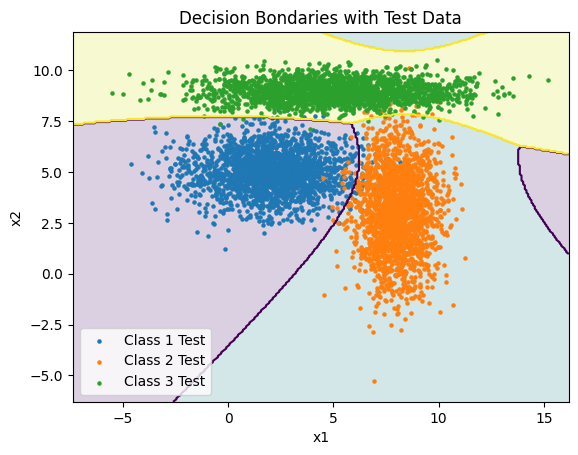

In [16]:
x_min=min(C1[:,0].min(),C2[:,0].min(),C3[:,0].min())-1
x_max=max(C1[:,0].max(),C2[:,0].max(),C3[:,0].max())+1
y_min=min(C1[:,1].min(),C2[:,1].min(),C3[:,1].min())-1
y_max=max(C1[:,1].max(),C2[:,1].max(),C3[:,1].max())+1

x_values=np.linspace(x_min,x_max,300)
y_values=np.linspace(y_min,y_max,300)
X_grid,Y_grid=np.meshgrid(x_values,y_values)
grid_points=np.column_stack((X_grid.ravel(),Y_grid.ravel()))
grid_predictions=classify(grid_points)
decision_grid=grid_predictions.reshape(X_grid.shape)

plt.contourf(X_grid,Y_grid,decision_grid,alpha=0.2)
plt.contour(X_grid,Y_grid,decision_grid,levels=[1.5,2.5])

plt.scatter(C1_test[:,0],C1_test[:,1],s=5,label="Class 1 Test")
plt.scatter(C2_test[:,0],C2_test[:,1],s=5,label="Class 2 Test")
plt.scatter(C3_test[:,0],C3_test[:,1],s=5,label="Class 3 Test")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Decision Bondaries with Test Data")
plt.legend()
plt.show()

### Receiver Operating Curve

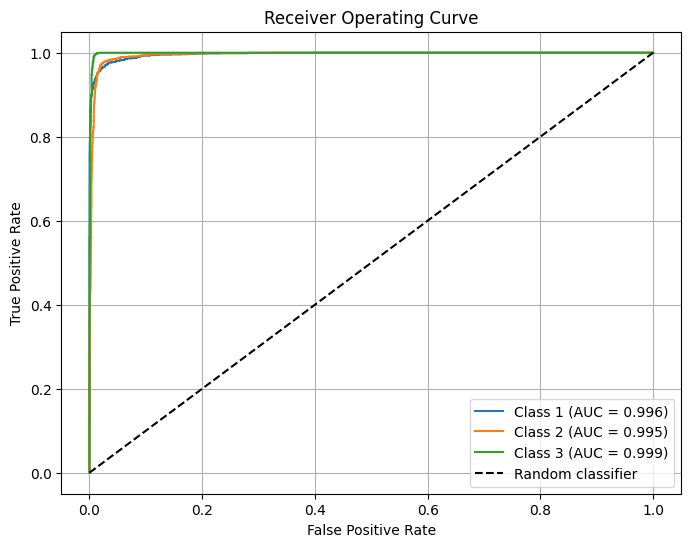

In [19]:
X_test=np.concatenate((C1_test,C2_test,C3_test))
scores=[]
for x in X_test:
  p1=gaussian_logpdf(x,mu1_est,cov1_est)
  p2=gaussian_logpdf(x,mu2_est,cov2_est)
  p3=gaussian_logpdf(x,mu3_est,cov3_est)
  scores.append([p1,p2,p3])
scores=np.array(scores)

def calculate_roc(true_labels,scores,class_label):
  actual=(true_labels==class_label).astype(int)
  order=np.argsort(scores)[::-1]
  actual=actual[order]
  P=np.sum(actual==1)
  N=np.sum(actual==0)
  TP=np.cumsum(actual==1)
  FP=np.cumsum(actual==0)
  TPR=np.concatenate(([0],TP/P,[1]))
  FPR=np.concatenate(([0],FP/N,[1]))
  return FPR,TPR

plt.figure(figsize=(8, 6))

for i in range(3):
  class_label=i+1
  FPR,TPR=calculate_roc(true_labels,scores[:,i],class_label)
  AUC=np.sum((FPR[1:]-FPR[:-1])*(TPR[1:]+TPR[:-1])/2)
  plt.plot(FPR,TPR,label=f'Class {class_label} (AUC = {AUC:.3f})')
plt.plot([0, 1], [0, 1], 'k--',label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Curve")
plt.legend()
plt.grid(True)
plt.show()